<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P4/E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

NIM = "2141720042"  # Sesuaikan dengan NIM Anda
BASE = '/content/drive/MyDrive/PCVK_2026/'
PARAM = {'L': 2}      # Jumlah level kuantisasi (L)

def floyd_steinberg_dither(gray_img, L=2):
    img = gray_img.astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    # Batasi nilai 0 - 255 lalu ubah ke uint8
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def floyd_steinberg_color(bgr_img, L=2):

    channels = cv.split(bgr_img)
    dithered_channels = [floyd_steinberg_dither(ch, L) for ch in channels]
    return cv.merge(dithered_channels)

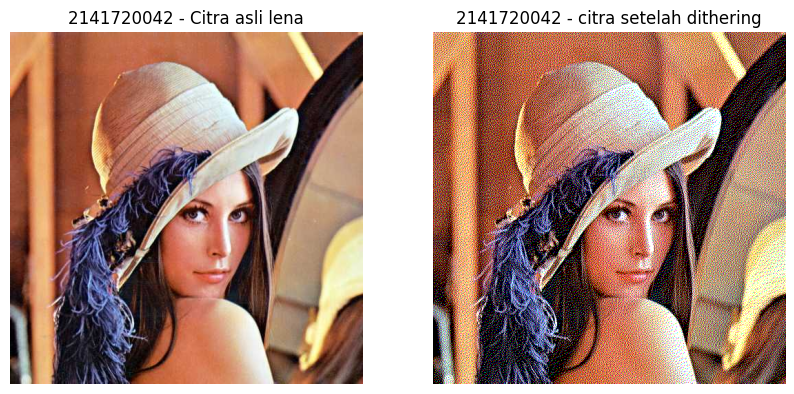

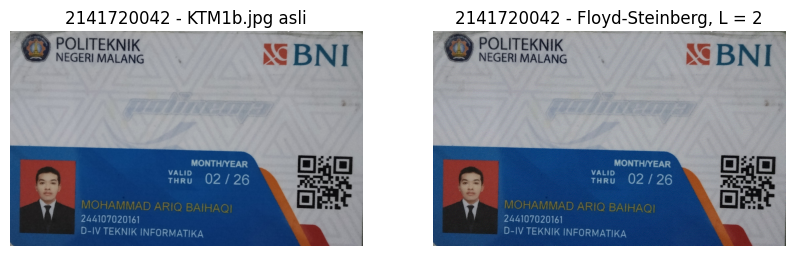

In [ ]:
lena_bgr = cv.imread(os.path.join(BASE, 'lena.jpg'))

if lena_bgr is not None:
    lena_dithered = floyd_steinberg_color(lena_bgr, L=PARAM['L'])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - Citra asli lena")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(lena_dithered, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - citra setelah dithering")
    plt.axis('off')
    plt.show()

ktm1b_bgr = cv.imread(os.path.join(BASE, 'KTM1b.jpg'))

if ktm1b_bgr is not None:
    ktm1b_dithered = floyd_steinberg_color(ktm1b_bgr, L=PARAM['L'])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - KTM1b.jpg asli")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(ktm1b_dithered, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - Floyd-Steinberg, L = {PARAM['L']}")
    plt.axis('off')
    plt.show()

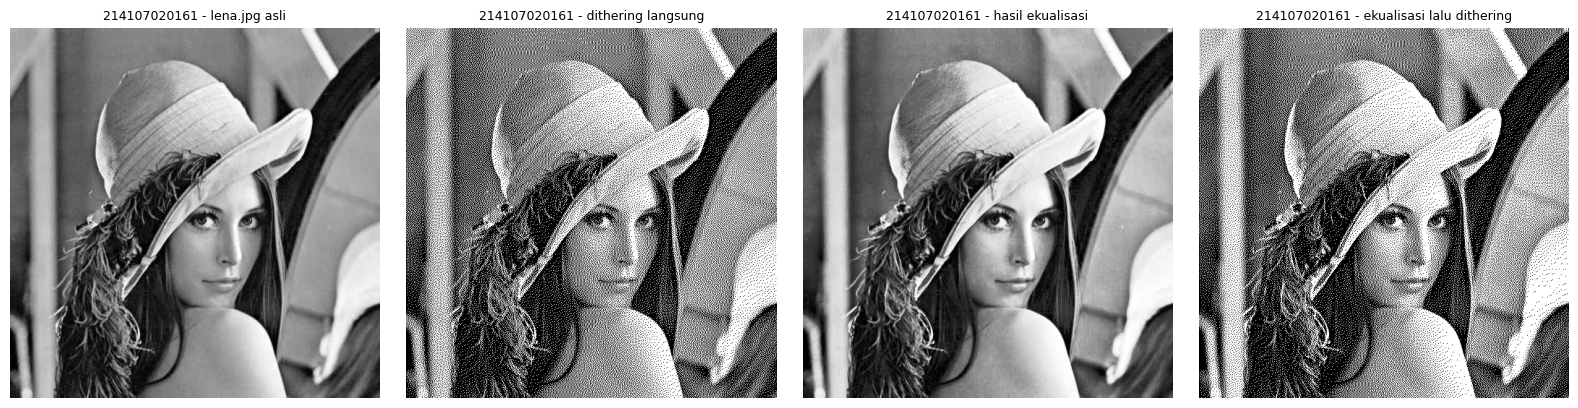

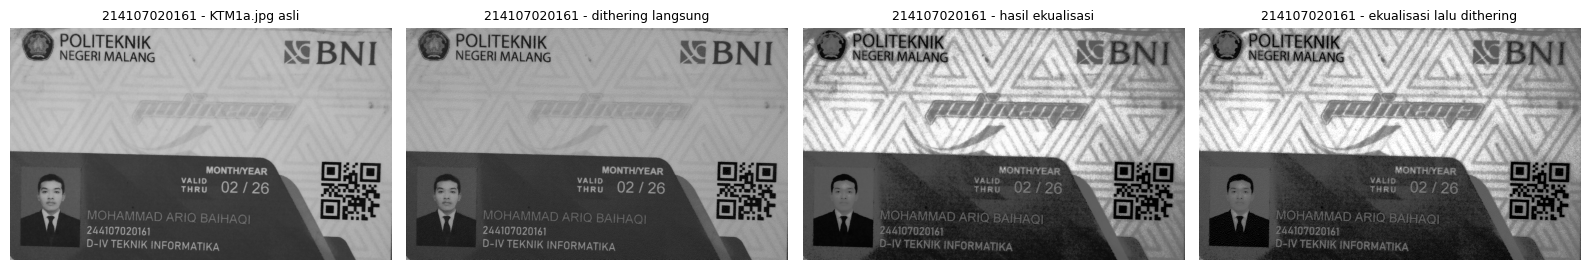

In [12]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/PCVK_2026/'
NIM = "214107020161"

# 2. Fungsi Dithering Floyd-Steinberg (Persyaratan fungsi)
def floyd_steinberg_dither(gray_img, L=2):
    img = gray_img.astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    return np.clip(img, 0, 255).astype(np.uint8)

def proses_soal_2(filename):
    path = os.path.join(BASE, filename)
    img_bgr = cv.imread(path)

    if img_bgr is None:
        print(f"File {filename} tidak ditemukan di path: {path}")
        return

    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    dither_direct = floyd_steinberg_dither(gray, L=2)

    eq = cv.equalizeHist(gray)

    eq_dither = floyd_steinberg_dither(eq, L=2)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(gray, cmap='gray')
    plt.title(f"{NIM} - {filename} asli", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(dither_direct, cmap='gray')
    plt.title(f"{NIM} - dithering langsung", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(eq, cmap='gray')
    plt.title(f"{NIM} - hasil ekualisasi", fontsize=9)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(eq_dither, cmap='gray')
    plt.title(f"{NIM} - ekualisasi lalu dithering", fontsize=9)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


proses_soal_2('lena.jpg')
proses_soal_2('KTM1a.jpg')